# Long and wide: reshaping the ED tracking board

**Master in Healthcare Analytics · Session: Data reshaping (long ↔ wide)**
Dataset: ED tracking board, Riverbend Community Hospital (fictional), calendar year 2025.

The same information can be laid out in a table in more than one way, and the layout decides what is easy and what is hard. This session is about the two layouts that matter most, **long** and **wide**, and about moving between them. We use one example throughout, the five timestamps of an ED visit, because it is a case where the hospital's own systems use one layout and analysts need the other.

**Plan.**

1. Long and wide, in healthcare terms.
2. The five timestamps are a wide table. `melt` turns them into a long **event log**.
3. What the long form makes easy: counting events, plotting all events on one clock, handling visits with missing events.
4. `pivot` turns the event log back into wide, and the waiting-time intervals fall out as column subtractions.
5. When `pivot` fails: duplicates, `pivot_table`, and `stack`/`unstack`.
6. Which layout for which job.

## 1. Long and wide, in healthcare terms

Think of a patient's vital signs over a shift. A nurse reads them from a **flowsheet**: one row per time point, one column per measurement (heart rate, blood pressure, temperature, …). That is the **wide** layout: one row per *thing* (a time point, a patient, a visit), one column per *variable*. It is the layout people read, and the layout most statistical methods expect.

The EHR does not store it that way. Underneath, each vital sign is one record: patient, time, *what was measured*, value. That is the **long** layout: one row per *observation*, with a column that names the variable. HL7 messages, FHIR `Observation` resources, laboratory result tables and audit logs are all long. It is the layout systems write, because a new kind of measurement is a new row rather than a new column, and a missing measurement is simply an absent row.

| | Long | Wide |
|---|---|---|
| One row is | one observation | one entity |
| Variable names live in | a column's *values* | the column *headers* |
| Missing measurement | no row | an empty cell |
| Adding a new measurement type | add rows | add a column |
| Natural for | storage, logs, plotting many series together | reading, statistics, arithmetic between variables |

In pandas, **`melt`** goes wide → long and **`pivot`** goes long → wide. Most real analyses use both, often several times.

## Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

BLUE, ORANGE, AQUA, YELLOW, MAGENTA, INK, MUTED, GRID = "#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#0b0b0b", "#898781", "#e1e0d9"
plt.rcParams.update({"figure.figsize": (10, 4), "axes.spines.top": False, "axes.spines.right": False,
                     "axes.edgecolor": MUTED, "axes.labelcolor": INK, "xtick.color": MUTED, "ytick.color": MUTED,
                     "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.6, "axes.axisbelow": True,
                     "font.family": "sans-serif", "font.size": 10})

BASE_URL = "https://raw.githubusercontent.com/thousandoaks/Python4DS-II/main/datasets/EDDataset/"
timestamp_cols = ["arrival_datetime", "triage_datetime", "provider_datetime", "decision_datetime", "departure_datetime"]
visits = pd.read_csv(BASE_URL + "ed_visits.csv", parse_dates=timestamp_cols)
print(visits.shape)

(44861, 31)


## 2. The five timestamps are a wide table

Every visit has (up to) five recorded events: arrival, triage, provider contact, disposition decision, departure. In `ed_visits.csv` they sit side by side as five columns, one row per visit. That is the wide layout. Keep only the visit ID, the disposition (we will need it later) and the five timestamps.

In [2]:
wide = visits[["visit_id", "disposition"] + timestamp_cols].copy()
wide.head(6)

,visit_id,disposition,arrival_datetime,triage_datetime,provider_datetime,decision_datetime,departure_datetime
0,E000001,Discharged,2025-01-01 00:34:00,2025-01-01 00:47:00,2025-01-01 01:01:00,2025-01-01 03:13:00,2025-01-01 03:39:00
1,E000002,Admitted,2025-01-01 00:51:00,2025-01-01 00:55:00,2025-01-01 01:20:00,2025-01-01 04:54:00,2025-01-01 06:22:00
2,E000003,Discharged,2025-01-01 01:57:00,2025-01-01 02:09:00,2025-01-01 02:18:00,2025-01-01 03:33:00,2025-01-01 03:54:00
3,E000004,LWBS,2025-01-01 03:51:00,2025-01-01 04:02:00,NaT,NaT,2025-01-01 04:15:00
4,E000005,Discharged,2025-01-01 04:05:00,2025-01-01 04:08:00,2025-01-01 04:11:00,2025-01-01 07:27:00,2025-01-01 07:46:00
5,E000006,Discharged,2025-01-01 04:16:00,2025-01-01 04:23:00,2025-01-01 04:44:00,2025-01-01 08:57:00,2025-01-01 09:17:00


Notice the blanks (`NaT`, "not a time") in the provider and decision columns of some rows. Those are the visits where the patient left before being seen: the event never happened, and in a wide table an event that never happened has to be an empty cell.

### `melt`: wide → long

`melt` takes the columns you name in `value_vars` and stacks them into two new columns: one holding the old column *name* (`var_name`) and one holding the *value* (`value_name`). The columns in `id_vars` are repeated on every new row so that each observation still knows which visit it belongs to.

In [3]:
events = wide.melt(
    id_vars=["visit_id", "disposition"],     # columns to keep as identifiers, repeated on every row
    value_vars=timestamp_cols,               # columns to stack
    var_name="event",                        # new column holding the old column names
    value_name="event_time",                 # new column holding the values
)
print("wide:", wide.shape, "   long:", events.shape)
events.head(8)

wide: (44861, 7)    long: (224305, 4)


,visit_id,disposition,event,event_time
0,E000001,Discharged,arrival_datetime,2025-01-01 00:34:00
1,E000002,Admitted,arrival_datetime,2025-01-01 00:51:00
2,E000003,Discharged,arrival_datetime,2025-01-01 01:57:00
3,E000004,LWBS,arrival_datetime,2025-01-01 03:51:00
4,E000005,Discharged,arrival_datetime,2025-01-01 04:05:00
5,E000006,Discharged,arrival_datetime,2025-01-01 04:16:00
6,E000007,Discharged,arrival_datetime,2025-01-01 06:14:00
7,E000008,Discharged,arrival_datetime,2025-01-01 06:23:00


Five columns of 44,861 rows have become one column of 224,305 rows (5 × 44,861). The column headers *arrival_datetime*, *triage_datetime*, … are now **values** in the `event` column. That is the essence of the transformation: information moved from the header into the data.

Two tidy-up steps make the event log easier to read: shorter event names, and sorting by visit and time so that each visit's events are consecutive and in order.

In [4]:
events["event"] = events["event"].str.replace("_datetime", "", regex=False)
events = events.sort_values(["visit_id", "event_time"]).reset_index(drop=True)
events.head(10)

,visit_id,disposition,event,event_time
0,E000001,Discharged,arrival,2025-01-01 00:34:00
1,E000001,Discharged,triage,2025-01-01 00:47:00
2,E000001,Discharged,provider,2025-01-01 01:01:00
3,E000001,Discharged,decision,2025-01-01 03:13:00
4,E000001,Discharged,departure,2025-01-01 03:39:00
5,E000002,Admitted,arrival,2025-01-01 00:51:00
6,E000002,Admitted,triage,2025-01-01 00:55:00
7,E000002,Admitted,provider,2025-01-01 01:20:00
8,E000002,Admitted,decision,2025-01-01 04:54:00
9,E000002,Admitted,departure,2025-01-01 06:22:00


This is now an **event log**: the layout a real tracking board writes to its database, one line per thing that happened. In a real system there would be more event types (bed assigned, nurse assessment, lab ordered, lab resulted, consult requested, …) and they would simply be more rows with different values of `event`; the table would not need a new column for each.

## 3. What the long form makes easy

### Missing events stop being missing values

In the wide table, a visit that ended as LWBS had blanks in two columns. What happened to those blanks in the long table?

In [5]:
print("Rows with a missing event_time in the long table:", events["event_time"].isna().sum())
print()
print("Events per visit, by disposition:")
print(events.dropna(subset=["event_time"]).groupby("disposition")["event"].count()
      .div(events.groupby("disposition")["visit_id"].nunique()).round(2).sort_values())

Rows with a missing event_time in the long table: 1919

Events per visit, by disposition:
disposition
LWBS           3.0
Eloped         4.0
AMA            5.0
Admitted       5.0
Discharged     5.0
Expired        5.0
Observation    5.0
Transferred    5.0
dtype: float64


`melt` carried the blanks over as rows with `NaT`, and a single `dropna` removes them. After that, the long table simply contains three events for an LWBS visit (arrival, triage, departure), four for an eloped visit, five for everyone else, with no empty cells anywhere. In the long layout, *an event that did not happen is a row that does not exist.* This is why systems store data long: nothing has to be recorded about the things that did not occur.

In [6]:
events = events.dropna(subset=["event_time"]).reset_index(drop=True)
print("Event log:", events.shape)
events["event"].value_counts()

Event log: (222386, 4)


event
arrival      44861
triage       44861
departure    44861
provider     43989
decision     43814
Name: count, dtype: int64

The event counts tell the story of the department in one table: every visit arrived and was triaged and departed; 872 fewer had a provider contact (the LWBS visits); 175 fewer still had a decision (the eloped visits).

### All events on one clock

A question that is awkward in the wide layout: *at what times of day do the different events happen?* Wide, that is five separate columns to process. Long, it is one `groupby` on two columns, because the event type is just another variable.

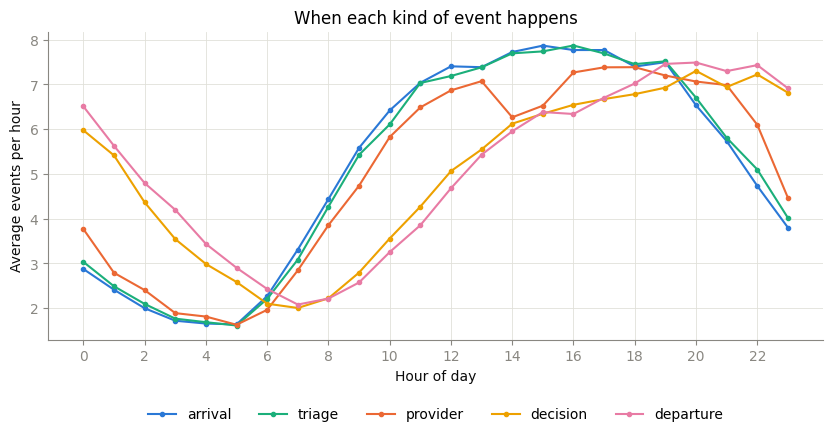

In [7]:
events["hour"] = events["event_time"].dt.hour
by_hour = events.groupby(["event", "hour"]).size().unstack("event") / 365     # average events per hour, per day
order = ["arrival", "triage", "provider", "decision", "departure"]
colors = dict(zip(order, [BLUE, AQUA, ORANGE, YELLOW, MAGENTA]))

fig, ax = plt.subplots()
for ev in order:
    ax.plot(by_hour.index, by_hour[ev], marker="o", markersize=3, linewidth=1.5, color=colors[ev], label=ev)
ax.set_xticks(range(0, 24, 2)); ax.set_xlabel("Hour of day"); ax.set_ylabel("Average events per hour")
ax.set_title("When each kind of event happens"); ax.legend(frameon=False, ncol=5, loc="upper center", bbox_to_anchor=(0.5, -0.18))
plt.show()

Each curve is shifted a little to the right of the one before it, because each event follows the previous one by some minutes or hours: arrivals peak mid-afternoon, departures peak in the evening. The gap between the arrival and departure curves at any hour is, roughly, patients accumulating in the department. This chart took one `groupby` because the events were long; from the wide table it would have taken five separate computations and a manual assembly.

(Notice `unstack("event")` in that cell. We will return to it in section 5: it is `pivot` under another name.)

## 4. `pivot`: long → wide, and the intervals fall out

Now the other direction. To compute how long patients waited we need each visit's events *side by side* again, so that we can subtract one from another. `pivot` does exactly this: it takes the values of one column (`event`) and spreads them out as new column headers.

- `index` — what becomes one row (the visit).
- `columns` — the column whose values become the new headers (the event type).
- `values` — what fills the cells (the timestamp).

In [8]:
back = events.pivot(index="visit_id", columns="event", values="event_time")
back = back[order]                       # put the columns in event order
print(back.shape)
back.head(6)

(44861, 5)


event,arrival,triage,provider,decision,departure
visit_id,,,,,
E000001,2025-01-01 00:34:00,2025-01-01 00:47:00,2025-01-01 01:01:00,2025-01-01 03:13:00,2025-01-01 03:39:00
E000002,2025-01-01 00:51:00,2025-01-01 00:55:00,2025-01-01 01:20:00,2025-01-01 04:54:00,2025-01-01 06:22:00
E000003,2025-01-01 01:57:00,2025-01-01 02:09:00,2025-01-01 02:18:00,2025-01-01 03:33:00,2025-01-01 03:54:00
E000004,2025-01-01 03:51:00,2025-01-01 04:02:00,NaT,NaT,2025-01-01 04:15:00
E000005,2025-01-01 04:05:00,2025-01-01 04:08:00,2025-01-01 04:11:00,2025-01-01 07:27:00,2025-01-01 07:46:00
E000006,2025-01-01 04:16:00,2025-01-01 04:23:00,2025-01-01 04:44:00,2025-01-01 08:57:00,2025-01-01 09:17:00


Back to one row per visit and one column per event. Two things are worth noticing. First, the visits whose events were absent from the long table now have empty cells again: `pivot` had to create a cell for every visit × event combination, and had nothing to put in some of them. Information about "did not happen" that was implicit in the long layout has become explicit `NaT` in the wide one. Second, the column headers are values that came *out* of the data; this is the reverse of what `melt` did.

With the events side by side, the waiting-time measures are subtractions between columns:

In [9]:
intervals = pd.DataFrame({
    "door_to_triage_min": (back["triage"] - back["arrival"]).dt.total_seconds() / 60,
    "door_to_provider_min": (back["provider"] - back["arrival"]).dt.total_seconds() / 60,
    "decision_to_departure_min": (back["departure"] - back["decision"]).dt.total_seconds() / 60,
    "ed_los_min": (back["departure"] - back["arrival"]).dt.total_seconds() / 60,
})
intervals.describe().round(0).loc[["count", "50%", "mean", "max"]]

,door_to_triage_min,door_to_provider_min,decision_to_departure_min,ed_los_min
count,44861.0,43989.0,43814.0,44861.0
50%,10.0,37.0,28.0,226.0
mean,11.0,46.0,44.0,254.0
max,98.0,574.0,824.0,1506.0


These are the derived columns that `ed_visits.csv` ships with, recomputed from scratch. The `count` row differs by column for the same structural reason as before: an interval that ends at an event that never happened is undefined.

Check that our recomputation agrees with the columns in the file:

In [10]:
original = visits.set_index("visit_id")[intervals.columns]
agree = (intervals - original).abs().le(1) | (intervals.isna() & original.isna())
print("Every recomputed interval agrees with the shipped column (to within a minute):", bool(agree.all().all()))

Every recomputed interval agrees with the shipped column (to within a minute): True


### The round trip

Wide → `melt` → long → `pivot` → wide. The two tables at either end hold the same information, and each made one thing easy that the other made awkward: the long form let us count and plot events by type without caring how many types there were; the wide form let us do arithmetic between events of the same visit.

## 5. When `pivot` fails: duplicates, `pivot_table`, and `stack`/`unstack`

### Duplicates

`pivot` insists that each (index, columns) pair occur **once**: one visit has one arrival time. Suppose we tried to pivot the event log with the *patient* as the row instead of the visit. Patients with several visits have several arrivals, so the (patient, "arrival") cell would need to hold several values, and `pivot` refuses:

In [11]:
events_p = events.merge(visits[["visit_id", "patient_id"]], on="visit_id")
try:
    events_p.pivot(index="patient_id", columns="event", values="event_time")
except ValueError as e:
    print("ValueError:", str(e)[:110], "...")

ValueError: Index contains duplicate entries, cannot reshape ...


### `pivot_table`: pivot with an aggregation

When a cell can receive several values, you must say how to combine them. `pivot_table` is `pivot` plus an aggregation function (`aggfunc`): count them, take the first, the mean, the maximum, whatever the question needs. Here, the number of events of each type per patient is a reasonable thing to want, so `aggfunc="size"`.

In [12]:
per_patient = events_p.pivot_table(index="patient_id", columns="event", values="event_time", aggfunc="size", fill_value=0)
per_patient = per_patient[order]
per_patient.sort_values("arrival", ascending=False).head(5)

event,arrival,triage,provider,decision,departure
patient_id,,,,,
P006301,24,24,24,24,24
P009259,23,23,22,22,23
P002223,22,22,22,22,22
P001875,19,19,19,19,19
P103320,19,19,19,19,19


One row per patient, one column per event type, cells holding counts. Read across a row: the second patient had 23 arrivals in the year but only 22 provider contacts and 22 decisions, so one of those visits ended before a provider was seen. `fill_value=0` matters: a patient who never eloped should show 0 decisions missing, not NaN.

The rule of thumb: use `pivot` when you are *rearranging* values (each goes to exactly one cell) and `pivot_table` when you are *summarising* them (several may land in a cell). Every crosstab and every heatmap you have seen in this programme was a `pivot_table`.

### `stack` and `unstack`: the same idea on a `groupby` result

In section 3 we used `unstack("event")` after a `groupby`. A `groupby` on two columns returns a Series with a two-level index (event, hour), which is a long layout in disguise: one row per (event, hour) pair. `unstack` moves one of those index levels into the column headers, which is exactly what `pivot` does; `stack` moves column headers back into the index, which is what `melt` does. Same transformations, different starting point.

In [13]:
long_counts = events.groupby(["event", "hour"]).size()          # two-level index: long
print(type(long_counts).__name__, "with index levels", long_counts.index.names)
print(long_counts.head(4))
print()
wide_counts = long_counts.unstack("event")                         # event -> column headers: wide
print("after unstack:", wide_counts.shape)
print()
back_long = wide_counts.stack()                                    # headers -> index: long again
back_long = back_long.swaplevel().sort_index()                     # stack puts the new level last; restore (event, hour) order
print("after stack:", back_long.shape, "| identical to the original:", bool(back_long.equals(long_counts.sort_index())))

Series with index levels ['event', 'hour']
event    hour
arrival  0       1048
         1        879
         2        728
         3        626
dtype: int64

after unstack: (24, 5)

after stack: (120,) | identical to the original: True


## 6. Which layout for which job

| You want to… | Use | Because |
|---|---|---|
| Store or log events, results, observations | long | new types are rows, absences are simply missing rows |
| Plot several series on one axis with one loop | long | the series name is a column you can group on |
| Count or summarise by type | long + `groupby` | one grouping key instead of one column per type |
| Do arithmetic between variables of the same entity | wide | subtraction and comparison work column to column |
| Feed a statistical model (one row per case) | wide | models want one column per variable |
| Show a table to a person | wide | headers are how people read |

And the tools:

| From | To | Tool | Note |
|---|---|---|---|
| wide | long | `melt(id_vars, value_vars, var_name, value_name)` | blanks become rows with NaN; `dropna` afterwards |
| long | wide | `pivot(index, columns, values)` | one value per cell, or it fails |
| long | wide (summarised) | `pivot_table(…, aggfunc, fill_value)` | every crosstab and heatmap |
| two-level index | columns | `unstack(level)` | `pivot` for `groupby` results |
| columns | index | `stack()` | `melt` for `groupby` results |

The lesson from the tracking board: the hospital's systems record what happened as a **long event log**, and every waiting-time measure on the quality dashboard comes from **pivoting that log wide** and subtracting columns. Knowing which layout you are looking at, and how to get to the other one, is most of the work.